# Infecar Data Analysis Notebook

Este notebook analiza el dataset original de la estación en:
`/Users/oroncal/workspace/projects/picota/runtime.test/data/infecar.csv`

Objetivos:
1. Calidad básica del dato y estructura.
2. Correlaciones con `generatedActivePower`.
3. Detección de outliers.
4. Evaluar capacidad predictiva de `generatedActivePower` con modelos simples.
5. Valorar si se cumplen relaciones esperadas (metamórficas):
   - `Infecar.radiation` ↑ => `generatedActivePower` no debería bajar.
   - `cellTemperature` ↑ => `generatedActivePower` debería tender a bajar (si hubiese efecto de eficiencia dominante).

In [22]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.dummy import DummyRegressor

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)
plt.style.use('default')

In [23]:
DATA_PATH = Path('/Users/oroncal/workspace/projects/picota/runtime.test/data/infecar.csv')
TARGET = 'generatedActivePower'
TIME_COL = 'instant'
AGGREGATION = 'hourly_mean'

assert DATA_PATH.exists(), f'No existe el fichero: {DATA_PATH}'

df_raw = pd.read_csv(DATA_PATH)
df_raw[TIME_COL] = pd.to_datetime(df_raw[TIME_COL], utc=True, errors='coerce')

numeric_cols_raw = [c for c in df_raw.columns if c != TIME_COL]
for c in numeric_cols_raw:
    df_raw[c] = pd.to_numeric(df_raw[c], errors='coerce')

df_raw = df_raw.sort_values(TIME_COL).reset_index(drop=True)

df_hourly = (
    df_raw
    .set_index(TIME_COL)
    .resample('1h')
    .mean(numeric_only=True)
    .dropna(how='all')
    .reset_index()
)

df = df_hourly.copy()
NUMERIC_COLS = [c for c in df.columns if c != TIME_COL]

print(f'raw_shape={df_raw.shape}')
print(f'hourly_shape={df.shape}')
print(f'aggregation={AGGREGATION}')
print(f'time range: {df[TIME_COL].min()} -> {df[TIME_COL].max()}')
df.head(3)

raw_shape=(232899, 8)
hourly_shape=(6221, 8)
aggregation=hourly_mean
time range: 2024-04-17 11:00:00+00:00 -> 2025-01-30 09:00:00+00:00


,instant,cellTemperature,Infecar.temperature,Infecar.radiation,generatedReactivePower,generatedActivePower,consumedReactivePower,consumedActivePower
0,2024-04-17 11:00:00+00:00,55.200000,38.250000,1681.150000,77.987500,77.987500,105.000000,105.000000
1,2024-04-17 12:00:00+00:00,57.325000,39.195833,1827.020833,120.725000,120.725000,117.385833,117.385833
2,2024-04-17 13:00:00+00:00,59.992308,40.023077,1821.653846,122.283846,122.283846,142.980769,142.980769


In [24]:
summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'null_%': (df.isna().mean() * 100).round(4),
    'n_unique': df.nunique(dropna=True),
})

print(f'duplicated rows: {int(df.duplicated().sum())}')
display(summary)
display(df[NUMERIC_COLS].describe().T)

duplicated rows: 0


,dtype,null_%,n_unique
instant,"datetime64[ns, UTC]",0.0,6221
cellTemperature,float64,0.0,5740
Infecar.temperature,float64,0.0,5498
Infecar.radiation,float64,0.0,3737
generatedReactivePower,float64,0.0,3777
generatedActivePower,float64,0.0,3777
consumedReactivePower,float64,0.0,5835
consumedActivePower,float64,0.0,5835


,count,mean,std,min,25%,50%,75%,max
cellTemperature,6221.0,26.858844,11.234701,9.697561,18.826190,22.051220,33.868293,62.119512
Infecar.temperature,6221.0,23.633010,5.749908,11.978049,19.447619,22.029268,27.525641,42.312195
Infecar.radiation,6221.0,370.702103,524.331349,0.000000,0.507317,23.330952,667.957500,2141.339024
generatedReactivePower,6221.0,21.738909,31.097737,0.014000,0.046341,0.973333,38.974634,153.900000
generatedActivePower,6221.0,21.738909,31.097737,0.014000,0.046341,0.973333,38.974634,153.900000
consumedReactivePower,6221.0,71.755855,32.086928,24.993902,50.648810,62.958333,84.975610,238.946429
consumedActivePower,6221.0,71.755855,32.086928,24.993902,50.648810,62.958333,84.975610,238.946429


In [25]:
# Buscar columnas casi idénticas (potencial leakage o redundancia fuerte)
near_duplicates = []
for i, c1 in enumerate(NUMERIC_COLS):
    for c2 in NUMERIC_COLS[i+1:]:
        same_ratio = ((df[c1] - df[c2]).abs() < 1e-9).mean()
        if same_ratio >= 0.99:
            near_duplicates.append((c1, c2, float(same_ratio)))

near_dup_df = pd.DataFrame(near_duplicates, columns=['col_1', 'col_2', 'same_ratio'])
display(near_dup_df if not near_dup_df.empty else pd.DataFrame({'info': ['No se encontraron columnas casi idénticas']}))

,col_1,col_2,same_ratio
0,generatedReactivePower,generatedActivePower,1.0
1,consumedReactivePower,consumedActivePower,1.0


,pearson_with_target,spearman_with_target
generatedReactivePower,1.000000,1.000000
generatedActivePower,1.000000,1.000000
Infecar.radiation,0.989946,0.907936
cellTemperature,0.943186,0.824939
Infecar.temperature,0.864949,0.784937
consumedReactivePower,0.261309,0.225171
consumedActivePower,0.261309,0.225171


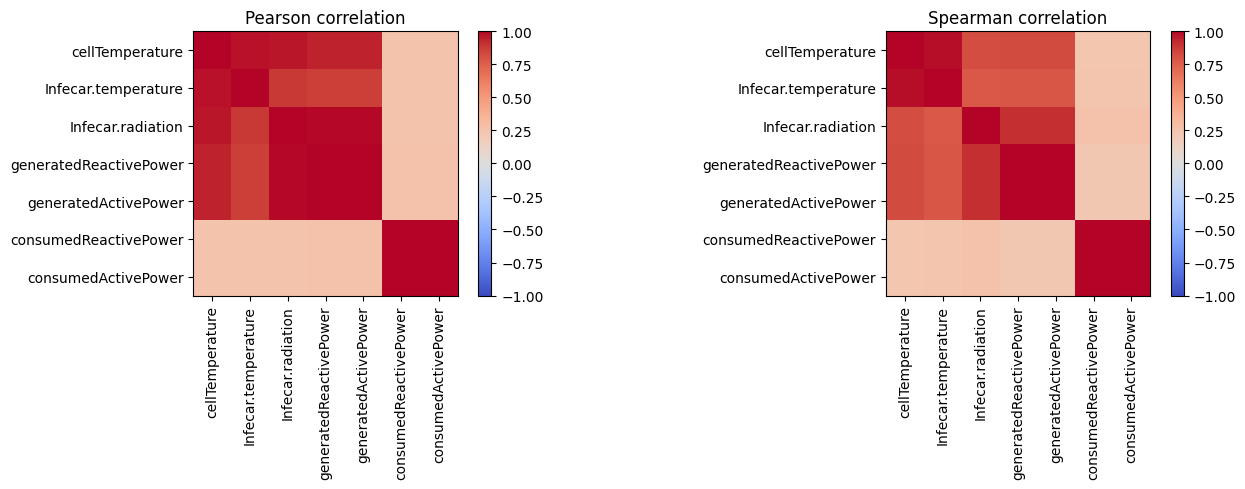

In [26]:
# Correlaciones
corr_pearson = df[NUMERIC_COLS].corr(method='pearson')
corr_spearman = df[NUMERIC_COLS].corr(method='spearman')

target_corr = pd.DataFrame({
    'pearson_with_target': corr_pearson[TARGET],
    'spearman_with_target': corr_spearman[TARGET],
}).sort_values('pearson_with_target', ascending=False)

display(target_corr)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
im0 = ax[0].imshow(corr_pearson.values, cmap='coolwarm', vmin=-1, vmax=1)
ax[0].set_title('Pearson correlation')
ax[0].set_xticks(range(len(NUMERIC_COLS)))
ax[0].set_yticks(range(len(NUMERIC_COLS)))
ax[0].set_xticklabels(NUMERIC_COLS, rotation=90)
ax[0].set_yticklabels(NUMERIC_COLS)
fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(corr_spearman.values, cmap='coolwarm', vmin=-1, vmax=1)
ax[1].set_title('Spearman correlation')
ax[1].set_xticks(range(len(NUMERIC_COLS)))
ax[1].set_yticks(range(len(NUMERIC_COLS)))
ax[1].set_xticklabels(NUMERIC_COLS, rotation=90)
ax[1].set_yticklabels(NUMERIC_COLS)
fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

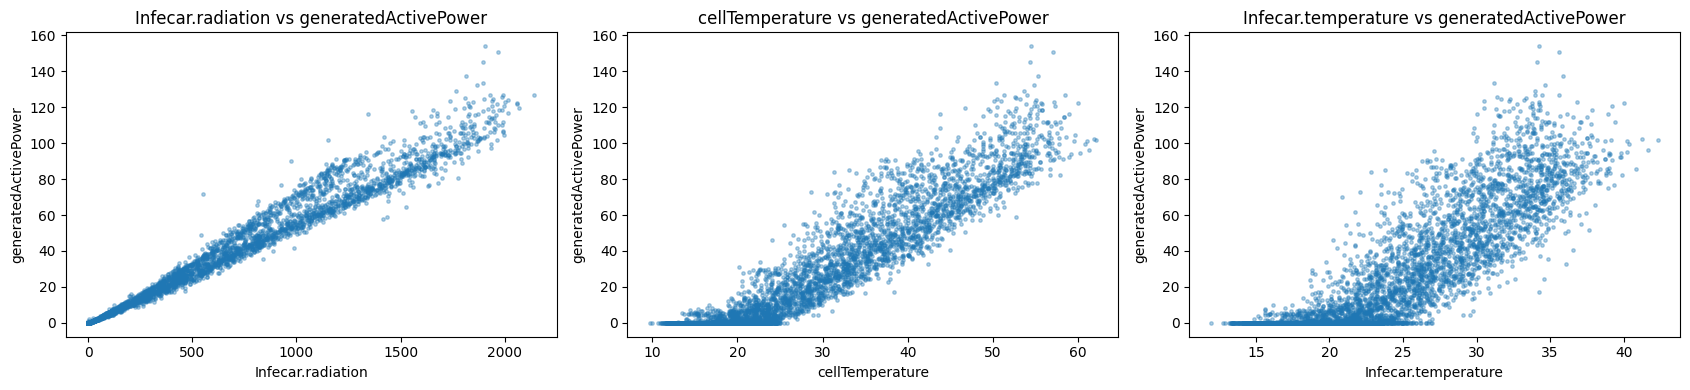

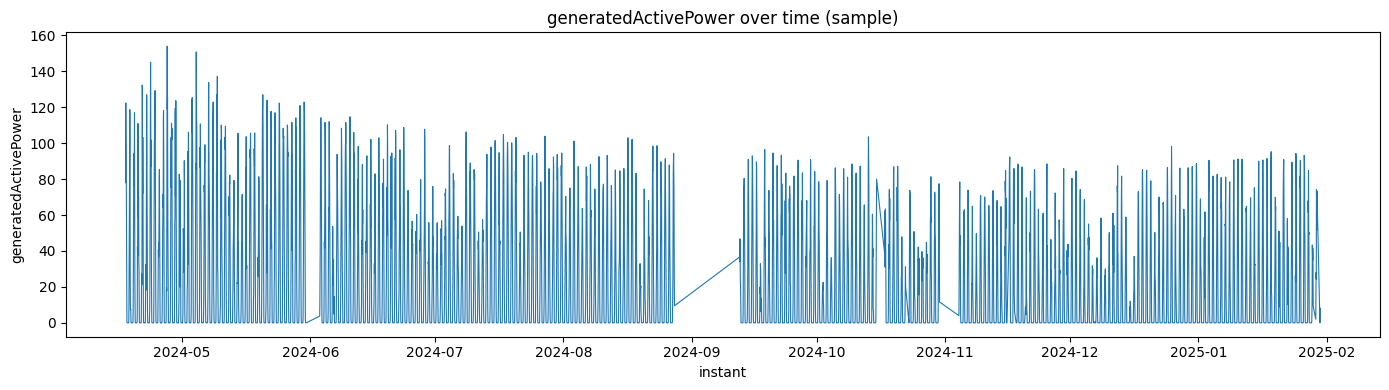

In [27]:
# Scatter de variables clave vs target (con sample para rendimiento)
plot_sample = df.sample(n=min(len(df), 12000), random_state=42).sort_values(TIME_COL)
features_to_plot = ['Infecar.radiation', 'cellTemperature', 'Infecar.temperature']

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, feat in zip(axes, features_to_plot):
    ax.scatter(plot_sample[feat], plot_sample[TARGET], s=6, alpha=0.35)
    ax.set_xlabel(feat)
    ax.set_ylabel(TARGET)
    ax.set_title(f'{feat} vs {TARGET}')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(plot_sample[TIME_COL], plot_sample[TARGET], linewidth=0.8)
ax.set_title(f'{TARGET} over time (sample)')
ax.set_xlabel('instant')
ax.set_ylabel(TARGET)
plt.tight_layout()
plt.show()

,feature,iqr_outlier_%,zscore_outlier_%,iqr_lo,iqr_hi
5,consumedReactivePower,5.112,1.816,-0.841391,136.465810
6,consumedActivePower,5.112,1.816,-0.841391,136.465810
2,Infecar.radiation,2.813,0.434,-1000.667957,1669.132774
3,generatedReactivePower,2.588,0.756,-58.346098,97.367073
4,generatedActivePower,2.588,0.756,-58.346098,97.367073
0,cellTemperature,0.804,0.080,-3.736963,56.431446
1,Infecar.temperature,0.193,0.048,7.330586,39.642674


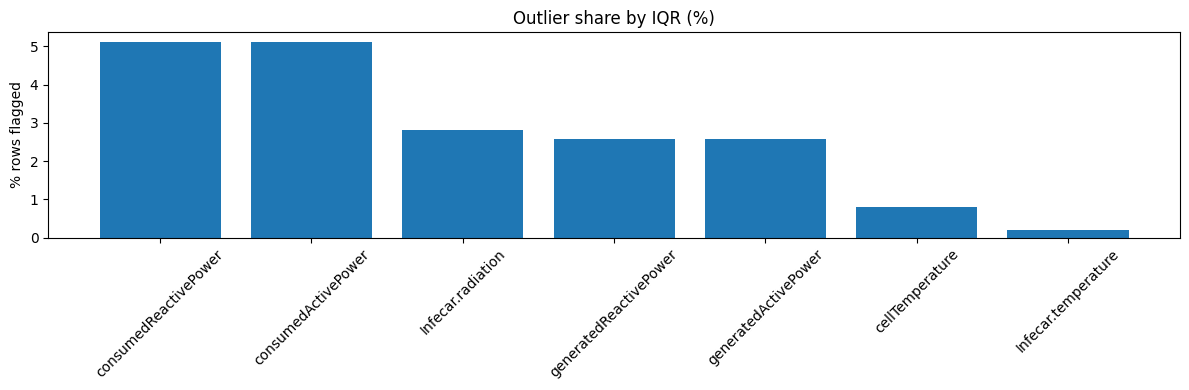

In [28]:
# Outliers por IQR y por z-score
outlier_rows = []
for c in NUMERIC_COLS:
    s = df[c].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    iqr_rate = ((df[c] < lo) | (df[c] > hi)).mean()

    std = s.std()
    if std == 0 or np.isnan(std):
        z_rate = 0.0
    else:
        z = (df[c] - s.mean()) / std
        z_rate = (z.abs() > 3).mean()

    outlier_rows.append({
        'feature': c,
        'iqr_outlier_%': round(float(iqr_rate * 100), 3),
        'zscore_outlier_%': round(float(z_rate * 100), 3),
        'iqr_lo': float(lo),
        'iqr_hi': float(hi),
    })

outlier_df = pd.DataFrame(outlier_rows).sort_values('iqr_outlier_%', ascending=False)
display(outlier_df)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(outlier_df['feature'], outlier_df['iqr_outlier_%'])
ax.set_title('Outlier share by IQR (%)')
ax.set_ylabel('% rows flagged')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [29]:
# Modelado: predicción de generatedActivePower a horizonte de 24 horas (t+24h)
MAX_ROWS_FOR_MODELING = 120_000
FORECAST_HORIZON_HOURS = 24
TARGET_FUTURE_COL = f'{TARGET}_t_plus_{FORECAST_HORIZON_HOURS}h'

df_model = (
    df[[TIME_COL] + NUMERIC_COLS]
    .sort_values(TIME_COL)
    .reset_index(drop=True)
    .copy()
)
df_model[TARGET_FUTURE_COL] = df_model[TARGET].shift(-FORECAST_HORIZON_HOURS)
if len(df_model) > MAX_ROWS_FOR_MODELING:
    keep_idx = np.linspace(0, len(df_model) - 1, MAX_ROWS_FOR_MODELING, dtype=int)
    df_model = df_model.iloc[keep_idx].reset_index(drop=True)

training_features = [
    c for c in NUMERIC_COLS
    if c not in {TARGET, 'generatedReactivePower'}
]
physical_subset = [
    'Infecar.radiation',
    'cellTemperature',
    'Infecar.temperature',
    'consumedReactivePower',
    'consumedActivePower',
]

feature_sets = {
    'training_features_without_generatedReactivePower': training_features,
    'physical_subset': [c for c in physical_subset if c in training_features],
}

models = {
    'dummy_mean': DummyRegressor(strategy='mean'),
    'random_forest': RandomForestRegressor(n_estimators=160, random_state=42, n_jobs=-1),
    'hist_gradient_boosting': HistGradientBoostingRegressor(random_state=42),
}

def evaluate_feature_set(feature_cols):
    d = (
        df_model[[TIME_COL] + feature_cols + [TARGET_FUTURE_COL]]
        .dropna()
        .sort_values(TIME_COL)
        .reset_index(drop=True)
    )
    X = d[feature_cols]
    y = d[TARGET_FUTURE_COL]
    pre = ColumnTransformer([
        ('num', Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), feature_cols)
    ])
    tscv = TimeSeriesSplit(n_splits=5)

    rows = []
    for model_name, model in models.items():
        pipe = Pipeline([('pre', pre), ('model', model)])
        scores = cross_validate(
            pipe, X, y, cv=tscv,
            scoring={'mae': 'neg_mean_absolute_error', 'r2': 'r2'},
            n_jobs=-1
        )
        rows.append({
            'model': model_name,
            'mae_mean': float((-scores['test_mae']).mean()),
            'mae_std': float((-scores['test_mae']).std()),
            'r2_mean': float(scores['test_r2'].mean()),
            'r2_std': float(scores['test_r2'].std()),
            'n_samples': int(len(d)),
            'forecast_horizon_hours': int(FORECAST_HORIZON_HOURS),
        })
    return pd.DataFrame(rows).sort_values('mae_mean')

print(f'Horizonte de forecast en modelado global: t+{FORECAST_HORIZON_HOURS}h')

model_results = {}
for set_name, feats in feature_sets.items():
    model_results[set_name] = evaluate_feature_set(feats)
    print(f'\
### Feature set: {set_name} ({len(feats)} vars)')
    display(model_results[set_name])

Horizonte de forecast en modelado global: t+24h
### Feature set: training_features_without_generatedReactivePower (5 vars)


,model,mae_mean,mae_std,r2_mean,r2_std,n_samples,forecast_horizon_hours
1,random_forest,8.841946,0.783828,0.659733,0.103333,6197,24
2,hist_gradient_boosting,9.013912,1.006502,0.665462,0.095993,6197,24
0,dummy_mean,25.794811,1.964574,-0.059196,0.047808,6197,24


### Feature set: physical_subset (5 vars)


,model,mae_mean,mae_std,r2_mean,r2_std,n_samples,forecast_horizon_hours
1,random_forest,8.830710,0.788879,0.659956,0.103569,6197,24
2,hist_gradient_boosting,9.014276,1.006154,0.665454,0.095992,6197,24
0,dummy_mean,25.794811,1.964574,-0.059196,0.047808,6197,24


,relation,spearman,pairwise_violation_rate,pairwise_compared,binned_step_violation_rate,binned_steps
0,radiation_up => active_power_non_decreasing,0.907936,0.485997,607,0.210526,19
1,cellTemperature_up => active_power_non_increasing,0.824939,0.370370,27,0.894737,19


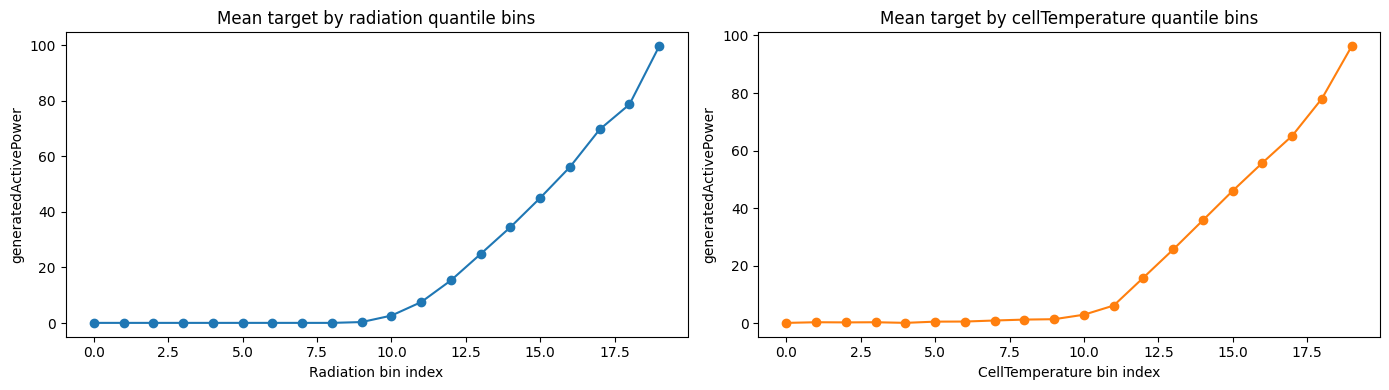

In [30]:
# Chequeo de relaciones/metamórficas

def pairwise_violation_rate(x, y, expected='non_decreasing', min_delta_x=1e-9):
    idx = np.argsort(np.asarray(x))
    xs = np.asarray(x)[idx]
    ys = np.asarray(y)[idx]
    marks = []
    for i in range(len(xs) - 1):
        dx = xs[i + 1] - xs[i]
        if abs(dx) < min_delta_x:
            continue
        dy = ys[i + 1] - ys[i]
        if expected == 'non_decreasing':
            marks.append(dy < 0)
        elif expected == 'non_increasing':
            marks.append(dy > 0)
        else:
            raise ValueError(expected)
    if not marks:
        return np.nan, 0
    return float(np.mean(marks)), int(len(marks))

def binned_monotonic_step_violations(x, y, expected='non_decreasing', q=20):
    tmp = pd.DataFrame({'x': x, 'y': y}).dropna()
    bins = pd.qcut(tmp['x'], q=q, duplicates='drop')
    means = tmp.groupby(bins, observed=False)['y'].mean().values
    if len(means) < 2:
        return np.nan, 0, means
    steps = np.diff(means)
    if expected == 'non_decreasing':
        viol = int(np.sum(steps < 0))
    elif expected == 'non_increasing':
        viol = int(np.sum(steps > 0))
    else:
        raise ValueError(expected)
    return float(viol / len(steps)), int(len(steps)), means

relations = []

# Relación 1: radiación no debería bajar potencia
v_pair, n_pair = pairwise_violation_rate(df['Infecar.radiation'], df[TARGET], expected='non_decreasing', min_delta_x=1.0)
v_bin, n_bin, means_bin = binned_monotonic_step_violations(df['Infecar.radiation'], df[TARGET], expected='non_decreasing', q=20)
relations.append({
    'relation': 'radiation_up => active_power_non_decreasing',
    'spearman': float(df['Infecar.radiation'].corr(df[TARGET], method='spearman')),
    'pairwise_violation_rate': v_pair,
    'pairwise_compared': n_pair,
    'binned_step_violation_rate': v_bin,
    'binned_steps': n_bin,
})

# Relación 2: subir cellTemperature debería tender a bajar potencia
v_pair2, n_pair2 = pairwise_violation_rate(df['cellTemperature'], df[TARGET], expected='non_increasing', min_delta_x=0.1)
v_bin2, n_bin2, means_bin2 = binned_monotonic_step_violations(df['cellTemperature'], df[TARGET], expected='non_increasing', q=20)
relations.append({
    'relation': 'cellTemperature_up => active_power_non_increasing',
    'spearman': float(df['cellTemperature'].corr(df[TARGET], method='spearman')),
    'pairwise_violation_rate': v_pair2,
    'pairwise_compared': n_pair2,
    'binned_step_violation_rate': v_bin2,
    'binned_steps': n_bin2,
})

relations_df = pd.DataFrame(relations)
display(relations_df)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(means_bin, marker='o')
ax[0].set_title('Mean target by radiation quantile bins')
ax[0].set_ylabel(TARGET)
ax[0].set_xlabel('Radiation bin index')

ax[1].plot(means_bin2, marker='o', color='tab:orange')
ax[1].set_title('Mean target by cellTemperature quantile bins')
ax[1].set_ylabel(TARGET)
ax[1].set_xlabel('CellTemperature bin index')

plt.tight_layout()
plt.show()

In [31]:
# Ejemplos concretos de contradicción en relaciones (consecutivos ordenados)
def top_contradictions(df_in, x_col, y_col, expected='non_decreasing', top_n=20, min_delta_x=1.0):
    d = df_in[[x_col, y_col, TIME_COL]].dropna().sort_values(x_col).reset_index(drop=True)
    rows = []
    for i in range(len(d) - 1):
        x0, x1 = d.loc[i, x_col], d.loc[i+1, x_col]
        y0, y1 = d.loc[i, y_col], d.loc[i+1, y_col]
        dx, dy = float(x1 - x0), float(y1 - y0)
        if abs(dx) < min_delta_x:
            continue
        violates = (dy < 0) if expected == 'non_decreasing' else (dy > 0)
        if violates:
            rows.append({
                'x0': float(x0), 'x1': float(x1), 'dx': dx,
                'y0': float(y0), 'y1': float(y1), 'dy': dy,
                't0': d.loc[i, TIME_COL], 't1': d.loc[i+1, TIME_COL],
            })
    out = pd.DataFrame(rows)
    if out.empty:
        return out
    if expected == 'non_decreasing':
        return out.sort_values('dy').head(top_n)
    return out.sort_values('dy', ascending=False).head(top_n)

rad_contra = top_contradictions(df, 'Infecar.radiation', TARGET, expected='non_decreasing', top_n=20, min_delta_x=25.0)
temp_contra = top_contradictions(df, 'cellTemperature', TARGET, expected='non_increasing', top_n=20, min_delta_x=1.0)

print('Top contradicciones: radiation_up => power_non_decreasing')
display(rad_contra)
print('Top contradicciones: cellTemperature_up => power_non_increasing')
display(temp_contra)

Top contradicciones: radiation_up => power_non_decreasing


""


Top contradicciones: cellTemperature_up => power_non_increasing


""


## Análisis por franja horaria

Separamos la serie (ya agregada por media horaria) en estas franjas:
- `madrugada_00_06`
- `mañana_06_12`
- `tarde_12_18`
- `noche_18_24`

Y recalculamos:
- correlaciones por franja,
- violaciones de relaciones monotónicas por franja,
- capacidad predictiva de `generatedActivePower` por franja.

Filas por franja horaria:


,n_rows
franja_horaria,
mañana_06_12,1571
tarde_12_18,1568
noche_18_24,1545
madrugada_00_06,1537


,franja_horaria,n_rows,corr_rad_pearson,corr_rad_spearman,corr_cellTemp_pearson,corr_cellTemp_spearman,viol_pair_rad_non_decreasing,viol_pair_rad_compared,viol_bins_rad_non_decreasing,viol_bins_rad_steps,viol_pair_temp_non_increasing,viol_pair_temp_compared,viol_bins_temp_non_increasing,viol_bins_temp_steps,target_mean
0,madrugada_00_06,1537,0.010115,0.012242,-0.016431,0.022039,NaN,0,0.444444,9,0.000000,3,0.444444,9,0.045938
1,mañana_06_12,1571,0.987153,0.994084,0.936042,0.936180,0.450281,533,0.000000,9,0.615385,13,1.000000,9,29.748221
2,noche_18_24,1545,0.990775,0.587589,0.640086,0.408098,0.435644,101,0.222222,9,0.666667,9,0.888889,9,1.174907
3,tarde_12_18,1568,0.970734,0.974843,0.888334,0.891447,0.507824,703,0.000000,9,0.583333,12,1.000000,9,55.240727


Horizonte de forecast por franja: t+24h


,franja_horaria,model,mae,r2,n_train,n_test,forecast_horizon_hours
0,madrugada_00_06,dummy_mean,0.003868,-0.002465,1059,454,24
1,madrugada_00_06,random_forest,0.008138,-0.074720,1059,454,24
2,madrugada_00_06,hist_gradient_boosting,0.008616,-0.083252,1059,454,24
3,mañana_06_12,hist_gradient_boosting,13.782026,0.336303,1082,465,24
4,mañana_06_12,random_forest,14.156091,0.352300,1082,465,24
5,mañana_06_12,dummy_mean,24.049278,-0.168391,1082,465,24
6,noche_18_24,random_forest,0.073216,-2.713314,1064,457,24
7,noche_18_24,hist_gradient_boosting,0.156735,-3.522456,1064,457,24
8,noche_18_24,dummy_mean,1.562989,-158.903551,1064,457,24
9,tarde_12_18,random_forest,26.003204,-0.151270,1080,464,24


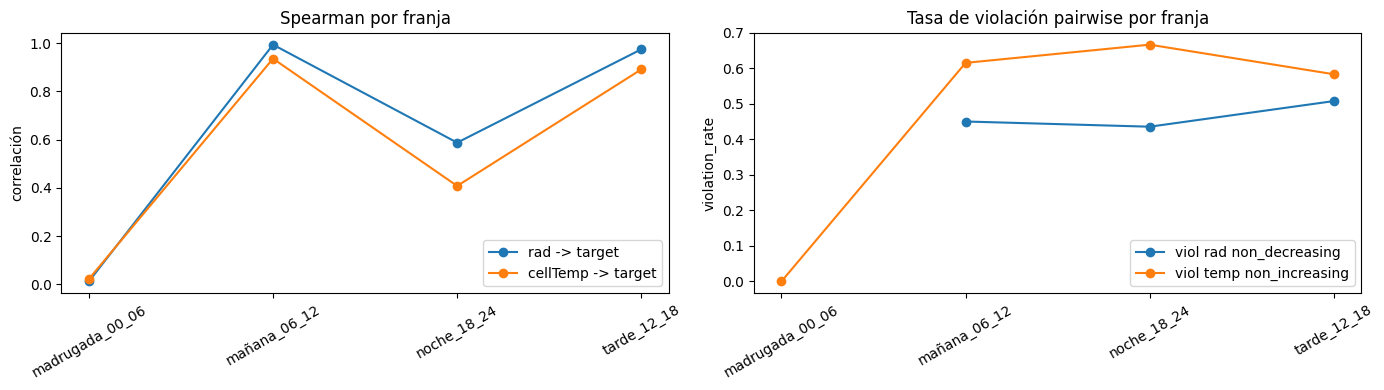

In [32]:
# Separación por franja horaria y recálculo de métricas
from sklearn.metrics import mean_absolute_error, r2_score

FORECAST_HORIZON_HOURS = int(globals().get('FORECAST_HORIZON_HOURS', 24))

def hour_band(hour: int) -> str:
    if 0 <= hour < 6:
        return 'madrugada_00_06'
    if 6 <= hour < 12:
        return 'mañana_06_12'
    if 12 <= hour < 18:
        return 'tarde_12_18'
    return 'noche_18_24'

SLOT_ORDER = ['madrugada_00_06', 'mañana_06_12', 'tarde_12_18', 'noche_18_24']

df_slots = df.copy()
df_slots['hour'] = df_slots[TIME_COL].dt.hour.astype(int)
df_slots['franja_horaria'] = pd.Categorical(
    df_slots['hour'].map(hour_band),
    categories=SLOT_ORDER,
    ordered=True,
)

print('Filas por franja horaria:')
display(df_slots['franja_horaria'].value_counts(dropna=False).rename('n_rows').to_frame())

slot_rows = []
for slot, dfi in df_slots.groupby('franja_horaria', observed=True):
    dfi = dfi.dropna(subset=['Infecar.radiation', 'cellTemperature', TARGET]).copy()
    if len(dfi) < 25:
        continue

    v_pair_rad, n_pair_rad = pairwise_violation_rate(
        dfi['Infecar.radiation'],
        dfi[TARGET],
        expected='non_decreasing',
        min_delta_x=1.0,
    )
    v_bin_rad, n_bin_rad, _ = binned_monotonic_step_violations(
        dfi['Infecar.radiation'],
        dfi[TARGET],
        expected='non_decreasing',
        q=10,
    )

    v_pair_temp, n_pair_temp = pairwise_violation_rate(
        dfi['cellTemperature'],
        dfi[TARGET],
        expected='non_increasing',
        min_delta_x=0.25,
    )
    v_bin_temp, n_bin_temp, _ = binned_monotonic_step_violations(
        dfi['cellTemperature'],
        dfi[TARGET],
        expected='non_increasing',
        q=10,
    )

    slot_rows.append({
        'franja_horaria': slot,
        'n_rows': int(len(dfi)),
        'corr_rad_pearson': float(dfi['Infecar.radiation'].corr(dfi[TARGET], method='pearson')),
        'corr_rad_spearman': float(dfi['Infecar.radiation'].corr(dfi[TARGET], method='spearman')),
        'corr_cellTemp_pearson': float(dfi['cellTemperature'].corr(dfi[TARGET], method='pearson')),
        'corr_cellTemp_spearman': float(dfi['cellTemperature'].corr(dfi[TARGET], method='spearman')),
        'viol_pair_rad_non_decreasing': float(v_pair_rad),
        'viol_pair_rad_compared': int(n_pair_rad),
        'viol_bins_rad_non_decreasing': float(v_bin_rad),
        'viol_bins_rad_steps': int(n_bin_rad),
        'viol_pair_temp_non_increasing': float(v_pair_temp),
        'viol_pair_temp_compared': int(n_pair_temp),
        'viol_bins_temp_non_increasing': float(v_bin_temp),
        'viol_bins_temp_steps': int(n_bin_temp),
        'target_mean': float(dfi[TARGET].mean()),
    })

franja_rel_df = pd.DataFrame(slot_rows).sort_values('franja_horaria').reset_index(drop=True)
display(franja_rel_df)

slot_models = {
    'dummy_mean': DummyRegressor(strategy='mean'),
    'random_forest': RandomForestRegressor(n_estimators=120, random_state=42, n_jobs=-1),
    'hist_gradient_boosting': HistGradientBoostingRegressor(random_state=42),
}

def temporal_holdout_metrics(
    dfi: pd.DataFrame,
    feature_cols: list[str],
    model,
    train_ratio: float = 0.7,
    forecast_horizon_hours: int = 24,
):
    d = (
        dfi[[TIME_COL] + feature_cols + [TARGET]]
        .dropna()
        .sort_values(TIME_COL)
        .reset_index(drop=True)
    )
    d['target_future'] = d[TARGET].shift(-forecast_horizon_hours)
    d = d.dropna(subset=['target_future']).reset_index(drop=True)

    n = len(d)
    n_train = int(n * train_ratio)
    n_test = n - n_train
    if n_train < 30 or n_test < 15:
        return None

    X_train = d.iloc[:n_train][feature_cols]
    y_train = d.iloc[:n_train]['target_future']
    X_test = d.iloc[n_train:][feature_cols]
    y_test = d.iloc[n_train:]['target_future']

    pre = ColumnTransformer([
        ('num', Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), feature_cols)
    ])
    pipe = Pipeline([('pre', pre), ('model', model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    return {
        'mae': float(mean_absolute_error(y_test, pred)),
        'r2': float(r2_score(y_test, pred)),
        'n_train': int(n_train),
        'n_test': int(n_test),
        'forecast_horizon_hours': int(forecast_horizon_hours),
    }

print(f'Horizonte de forecast por franja: t+{FORECAST_HORIZON_HOURS}h')

slot_model_rows = []
for slot, dfi in df_slots.groupby('franja_horaria', observed=True):
    for model_name, model in slot_models.items():
        m = temporal_holdout_metrics(
            dfi,
            training_features,
            model,
            forecast_horizon_hours=FORECAST_HORIZON_HOURS,
        )
        if m is None:
            continue
        slot_model_rows.append({
            'franja_horaria': slot,
            'model': model_name,
            'mae': m['mae'],
            'r2': m['r2'],
            'n_train': m['n_train'],
            'n_test': m['n_test'],
            'forecast_horizon_hours': m['forecast_horizon_hours'],
        })

franja_model_df = pd.DataFrame(slot_model_rows).sort_values(['franja_horaria', 'mae']).reset_index(drop=True)
display(franja_model_df)

if not franja_rel_df.empty:
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))

    ax[0].plot(franja_rel_df['franja_horaria'], franja_rel_df['corr_rad_spearman'], marker='o', label='rad -> target')
    ax[0].plot(franja_rel_df['franja_horaria'], franja_rel_df['corr_cellTemp_spearman'], marker='o', label='cellTemp -> target')
    ax[0].set_title('Spearman por franja')
    ax[0].set_ylabel('correlación')
    ax[0].tick_params(axis='x', rotation=30)
    ax[0].legend()

    ax[1].plot(franja_rel_df['franja_horaria'], franja_rel_df['viol_pair_rad_non_decreasing'], marker='o', label='viol rad non_decreasing')
    ax[1].plot(franja_rel_df['franja_horaria'], franja_rel_df['viol_pair_temp_non_increasing'], marker='o', label='viol temp non_increasing')
    ax[1].set_title('Tasa de violación pairwise por franja')
    ax[1].set_ylabel('violation_rate')
    ax[1].tick_params(axis='x', rotation=30)
    ax[1].legend()

    plt.tight_layout()
    plt.show()

## Interpretación esperada

Pistas importantes para la lectura de resultados:
- El análisis principal se ejecuta sobre serie agregada a media horaria (`resample('1h').mean()`).
- `generatedReactivePower` es prácticamente idéntica a `generatedActivePower` (leakage), por eso se excluye del bloque de modelado principal.
- Las reglas monotónicas estrictas sobre datos observacionales suelen fallar por confusión (hora del día, nubosidad, operación de planta, etc.).
- Una regla puede fallar a nivel punto-a-punto pero sostenerse en promedio por bins (tendencia agregada).
- Para validar relaciones físicas conviene construir comparaciones condicionadas (mismo contexto) y no solo orden global.